import libraries

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [6]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 60000
Test size: 10000


Low-Data Subsets

In [8]:
def get_subset(dataset, size):
    indices = np.random.choice(len(dataset), size, replace=False)
    return Subset(dataset, indices)

train_subset_100 = get_subset(train_dataset, 100)
train_subset_500 = get_subset(train_dataset, 500)
train_subset_1000 = get_subset(train_dataset, 1000)

print(len(train_subset_100), len(train_subset_500), len(train_subset_1000))

100 500 1000


DataLoaders

In [9]:
batch_size = 32

train_loader = DataLoader(train_subset_1000, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Simple Baseline Model (MLP)

In [10]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        
        self.flatten = nn.Flatten()
        
        self.network = nn.Sequential(
            nn.Linear(32*32, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

model = SimpleMLP().to(device)
print(model)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


Define Loss and Optimizer

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training Function

In [12]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

Evaluation Function

In [13]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

Train for Few Epochs

In [9]:
epochs = 5

for epoch in range(epochs):
    loss = train(model, train_loader, optimizer, criterion)
    accuracy = evaluate(model, test_loader)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Test Accuracy: {accuracy:.2f}%")

Epoch 1/5, Loss: 1.5009, Test Accuracy: 54.53%
Epoch 2/5, Loss: 0.8635, Test Accuracy: 67.20%
Epoch 3/5, Loss: 0.6596, Test Accuracy: 73.20%
Epoch 4/5, Loss: 0.6466, Test Accuracy: 73.58%
Epoch 5/5, Loss: 0.5543, Test Accuracy: 76.50%


Implement Small ViT

In [14]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=1, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        
        self.projection = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )
        
    def forward(self, x):
        x = self.projection(x)  # (B, embed_dim, H', W')
        x = x.flatten(2)        # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)   # (B, num_patches, embed_dim)
        return x

Small Vision Transformer

In [15]:
class SmallViT(nn.Module):
    def __init__(self, 
                 img_size=32, 
                 patch_size=4, 
                 embed_dim=128, 
                 num_heads=4, 
                 depth=2, 
                 num_classes=10):
        
        super().__init__()
        
        self.patch_embed = PatchEmbedding(img_size, patch_size, 1, embed_dim)
        num_patches = (img_size // patch_size) ** 2
        
        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # Positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim*4,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )
        
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )
        
    def forward(self, x):
        B = x.size(0)
        
        x = self.patch_embed(x)
        
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        x = x + self.pos_embed
        
        x = self.transformer(x)
        
        cls_output = x[:, 0]
        
        return self.mlp_head(cls_output)

Initialize Model

In [16]:
model = SmallViT().to(device)
print("Small ViT created")

Small ViT created


training

Define Loss + Optimizer

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

Train Function

In [18]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

Evaluate Function

In [19]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

Train the Small ViT

In [16]:
epochs = 5

for epoch in range(epochs):
    loss = train(model, train_loader, optimizer, criterion)
    accuracy = evaluate(model, test_loader)
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Test Accuracy: {accuracy:.2f}%")

Epoch 1/5 | Loss: 2.1135 | Test Accuracy: 22.21%
Epoch 2/5 | Loss: 1.8365 | Test Accuracy: 39.87%
Epoch 3/5 | Loss: 1.4431 | Test Accuracy: 40.38%
Epoch 4/5 | Loss: 1.2384 | Test Accuracy: 50.43%
Epoch 5/5 | Loss: 1.1108 | Test Accuracy: 59.09%


In [17]:
epochs = 15

for epoch in range(epochs):
    loss = train(model, train_loader, optimizer, criterion)
    accuracy = evaluate(model, test_loader)
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Test Accuracy: {accuracy:.2f}%")

Epoch 1/15 | Loss: 1.0542 | Test Accuracy: 61.56%
Epoch 2/15 | Loss: 0.9644 | Test Accuracy: 66.46%
Epoch 3/15 | Loss: 0.9297 | Test Accuracy: 65.33%
Epoch 4/15 | Loss: 0.8529 | Test Accuracy: 68.22%
Epoch 5/15 | Loss: 0.8162 | Test Accuracy: 70.75%
Epoch 6/15 | Loss: 0.7442 | Test Accuracy: 66.51%
Epoch 7/15 | Loss: 0.6997 | Test Accuracy: 68.33%
Epoch 8/15 | Loss: 0.6739 | Test Accuracy: 67.63%
Epoch 9/15 | Loss: 0.6296 | Test Accuracy: 70.66%
Epoch 10/15 | Loss: 0.6163 | Test Accuracy: 72.31%
Epoch 11/15 | Loss: 0.5549 | Test Accuracy: 67.24%
Epoch 12/15 | Loss: 0.5447 | Test Accuracy: 72.05%
Epoch 13/15 | Loss: 0.5431 | Test Accuracy: 72.20%
Epoch 14/15 | Loss: 0.5196 | Test Accuracy: 74.07%
Epoch 15/15 | Loss: 0.4901 | Test Accuracy: 74.14%


Define Quantum Device

In [20]:
import pennylane as qml

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)



Define Quantum Circuit
We use:

Angle encoding (simple + stable)

Parameterized rotations

Entanglement

Measure expectation values

In [21]:
@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):

    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    for i in range(n_qubits):
        qml.RX(weights[i], wires=i)

    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

Wrap Into PyTorch Layer

In [23]:
class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_qubits))

    def forward(self, x):
        batch_outputs = []

        for sample in x:
            q_out = quantum_circuit(sample, self.weights)
            q_out = torch.stack(q_out).float()
            batch_outputs.append(q_out)

        return torch.stack(batch_outputs)

Create Hybrid Model

In [24]:
class HybridViT_Augmented(nn.Module):
    def __init__(self):
        super().__init__()

        self.vit = SmallViT()

        # Quantum feature branch
        self.quantum_reduce = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, n_qubits)
        )

        self.quantum_layer = QuantumLayer()

        # Final classifier (128 + 4)
        self.classifier = nn.Linear(128 + n_qubits, 10)

    def forward(self, x):

        # ===== Transformer =====
        x = self.vit.patch_embed(x)

        B = x.size(0)
        cls_tokens = self.vit.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.vit.pos_embed
        x = self.vit.transformer(x)

        cls_output = x[:, 0]  # (B, 128)

        # ===== Quantum Branch =====
        q_input = self.quantum_reduce(cls_output)
        q_input = torch.tanh(q_input)  # stabilize rotations

        q_output = self.quantum_layer(q_input)

        # ===== Concatenate =====
        combined = torch.cat([cls_output, q_output], dim=1)

        return self.classifier(combined)

In [25]:
batch_size = 16

train_loader = DataLoader(train_subset_1000, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Initialize Hybrid Model

In [26]:
hybrid_model = HybridViT_Augmented().to(device)

optimizer = optim.Adam(
    hybrid_model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

epochs = 15

Training Function (Hybrid Version)

In [27]:
def train_hybrid(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

Evaluation Function

In [28]:
def evaluate_hybrid(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

Train for 2 Epochs First (Test Run)

In [42]:
epochs = 2  # first test

for epoch in range(epochs):
    loss = train_hybrid(hybrid_model, train_loader, optimizer, criterion)
    accuracy = evaluate_hybrid(hybrid_model, test_loader)
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Test Accuracy: {accuracy:.2f}%")

Epoch 1/2 | Loss: 2.3631 | Test Accuracy: 10.00%
Epoch 2/2 | Loss: 2.3283 | Test Accuracy: 10.00%


In [51]:
epochs = 10  # first test

for epoch in range(epochs):
    loss = train_hybrid(hybrid_model, train_loader, optimizer, criterion)
    accuracy = evaluate_hybrid(hybrid_model, test_loader)
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Test Accuracy: {accuracy:.2f}%")

Epoch 1/10 | Loss: 2.1075 | Test Accuracy: 26.36%
Epoch 2/10 | Loss: 1.6619 | Test Accuracy: 45.95%
Epoch 3/10 | Loss: 1.3017 | Test Accuracy: 53.76%
Epoch 4/10 | Loss: 1.1807 | Test Accuracy: 57.63%
Epoch 5/10 | Loss: 1.0174 | Test Accuracy: 60.10%
Epoch 6/10 | Loss: 0.9327 | Test Accuracy: 57.72%
Epoch 7/10 | Loss: 0.8500 | Test Accuracy: 68.59%
Epoch 8/10 | Loss: 0.8235 | Test Accuracy: 69.77%
Epoch 9/10 | Loss: 0.7740 | Test Accuracy: 64.14%
Epoch 10/10 | Loss: 0.7727 | Test Accuracy: 69.49%


In [29]:
def get_subset_loader(dataset, subset_size, batch_size=16):
    indices = torch.randperm(len(dataset))[:subset_size]
    subset = torch.utils.data.Subset(dataset, indices)
    
    loader = DataLoader(subset, batch_size=batch_size, shuffle=True)
    return loader

In [30]:
def run_experiment(model, train_loader, test_loader, epochs=15):
    
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
    
    # Final evaluation
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

Run All Experiments

In [31]:
subset_sizes = [100, 500, 1000]

results = {
    "samples": [],
    "classical": [],
    "hybrid": []
}

for size in subset_sizes:
    print(f"\nRunning experiments for {size} samples...")
    
    train_loader = get_subset_loader(train_dataset, size, batch_size=16)
    
    # Classical Model
    classical_model = SmallViT()
    acc_classical = run_experiment(classical_model, train_loader, test_loader)
    
    print(f"Classical Accuracy: {acc_classical:.2f}%")
    
    # Hybrid Model
    hybrid_model = HybridViT_Augmented()
    acc_hybrid = run_experiment(hybrid_model, train_loader, test_loader)
    
    print(f"Hybrid Accuracy: {acc_hybrid:.2f}%")
    
    # Store results
    results["samples"].append(size)
    results["classical"].append(acc_classical)
    results["hybrid"].append(acc_hybrid)


Running experiments for 100 samples...
Classical Accuracy: 32.58%
Hybrid Accuracy: 36.27%

Running experiments for 500 samples...
Classical Accuracy: 68.17%
Hybrid Accuracy: 69.23%

Running experiments for 1000 samples...
Classical Accuracy: 69.90%
Hybrid Accuracy: 72.60%


Print Comparison Table

In [32]:
print("\nFinal Results:")
print("Samples | Classical | Hybrid")

for i in range(len(results["samples"])):
    print(f"{results['samples'][i]} \t {results['classical'][i]:.2f}% \t {results['hybrid'][i]:.2f}%")


Final Results:
Samples | Classical | Hybrid
100 	 32.58% 	 36.27%
500 	 68.17% 	 69.23%
1000 	 69.90% 	 72.60%


Plot Graph

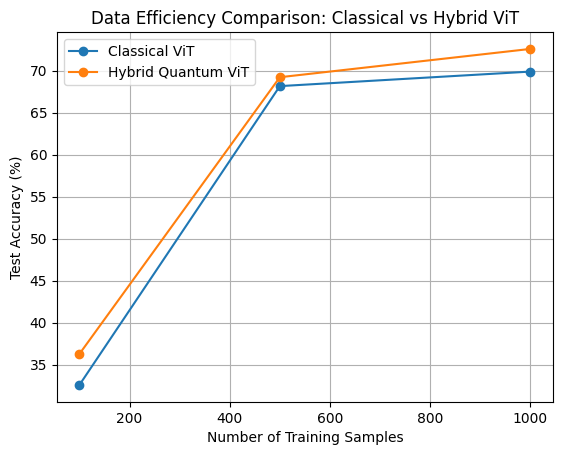

In [33]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(results["samples"], results["classical"], marker='o', label="Classical ViT")
plt.plot(results["samples"], results["hybrid"], marker='o', label="Hybrid Quantum ViT")

plt.xlabel("Number of Training Samples")
plt.ylabel("Test Accuracy (%)")
plt.title("Data Efficiency Comparison: Classical vs Hybrid ViT")

plt.legend()
plt.grid()

plt.show()

In [34]:
import pandas as pd

df = pd.DataFrame(results)
df.to_csv("results.csv", index=False)

print("Results saved as results.csv")

Results saved as results.csv
